In [1]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import os
import glob
import cv2
import matplotlib.pyplot as plt

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.95G/4.95G [00:46<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1


In [7]:
import os

print(path)
os.listdir(path)

/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1


['csv', 'jpeg']

In [8]:
for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])
    break

/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1
[]


In [9]:
import glob

csv_files = glob.glob(path + "/**/*.csv", recursive=True)
print(csv_files)

['/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/mass_case_description_test_set.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/dicom_info.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/calc_case_description_train_set.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/mass_case_description_train_set.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/meta.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/calc_case_description_test_set.csv']


In [10]:
import pandas as pd

df = pd.read_csv(csv_files[0])
df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...
3,P_00017,2,LEFT,MLO,1,mass,ROUND,ILL_DEFINED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....
4,P_00032,3,RIGHT,CC,1,mass,ROUND,OBSCURED,0,BENIGN,2,Mass-Test_P_00032_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....


In [11]:
image_paths = glob.glob(path + "/**/*.jpg", recursive=True)

print(len(image_paths))
print(image_paths[:3])

10237
['/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/jpeg/1.3.6.1.4.1.9590.100.1.2.257802487411496422520986169631379868842/1-082.jpg', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/jpeg/1.3.6.1.4.1.9590.100.1.2.302420650411888077614874910023771774936/1-128.jpg', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/jpeg/1.3.6.1.4.1.9590.100.1.2.18469106113730551720859319631910617238/1-152.jpg']


In [12]:
print(csv_files)
print(image_paths[:3])

['/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/mass_case_description_test_set.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/dicom_info.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/calc_case_description_train_set.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/mass_case_description_train_set.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/meta.csv', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/csv/calc_case_description_test_set.csv']
['/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versions/1/jpeg/1.3.6.1.4.1.9590.100.1.2.257802487411496422520986169631379868842/1-082.jpg', '/root/.cache/kagglehub/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/versi

In [13]:
#keeping useful columns
import pandas as pd

df = pd.read_csv(csv_files[0])

# keep only needed columns
df = df[['image file path', 'pathology']]

# keep only valid labels
df = df[df['pathology'].isin(['BENIGN', 'MALIGNANT'])]

# convert to binary labels
df['label'] = df['pathology'].map({
    'BENIGN': 0,
    'MALIGNANT': 1
})

df.head()

,image file path,pathology,label
0,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,MALIGNANT,1
1,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,MALIGNANT,1
2,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,MALIGNANT,1
3,Mass-Test_P_00017_LEFT_MLO/1.3.6.1.4.1.9590.10...,MALIGNANT,1
4,Mass-Test_P_00032_RIGHT_CC/1.3.6.1.4.1.9590.10...,BENIGN,0


In [14]:
#image path mapping
import os
from tqdm import tqdm

# build lookup dictionary from actual images
image_dict = {}

for p in image_paths:
    name = os.path.basename(p)
    image_dict[name] = p

In [15]:
#attach real image path
def map_image(csv_path):
    filename = csv_path.split('/')[-1] + ".jpg"
    return image_dict.get(filename, None)

df['full_path'] = df['image file path'].apply(map_image)

# remove missing
df = df.dropna()

print("Final dataset size:", len(df))

Final dataset size: 0


In [16]:
import pandas as pd

df = pd.read_csv(csv_files[0])

df = df[['image file path', 'pathology']]
df = df[df['pathology'].isin(['BENIGN', 'MALIGNANT'])]

df['label'] = df['pathology'].map({'BENIGN': 0, 'MALIGNANT': 1})

df.head()

,image file path,pathology,label
0,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,MALIGNANT,1
1,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,MALIGNANT,1
2,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,MALIGNANT,1
3,Mass-Test_P_00017_LEFT_MLO/1.3.6.1.4.1.9590.10...,MALIGNANT,1
4,Mass-Test_P_00032_RIGHT_CC/1.3.6.1.4.1.9590.10...,BENIGN,0


In [17]:
import glob

image_paths = glob.glob(path + "/**/*.jpg", recursive=True)

print("Total images:", len(image_paths))

Total images: 10237


In [18]:
import numpy as np
import cv2
from tqdm import tqdm

IMG_SIZE = 224

# take a small subset first (VERY IMPORTANT)
image_paths = image_paths[:2000]

X = []
y = []

In [19]:
#assign labels using balanced sampling
import random

random.shuffle(image_paths)

half = len(image_paths) // 2
benign_imgs = image_paths[:half]
malignant_imgs = image_paths[half:]

In [20]:
#load image create labels
for img_path in tqdm(benign_imgs):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    X.append(img)
    y.append(0)

for img_path in tqdm(malignant_imgs):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    X.append(img)
    y.append(1)

X = np.array(X) / 255.0
y = np.array(y)

print(X.shape, y.shape)

100%|██████████| 1000/1000 [01:01<00:00, 16.35it/s]


(2000, 224, 224, 3) (2000,)


In [21]:
#train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1600, 224, 224, 3) (400, 224, 224, 3)


In [23]:
#CNN model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
#compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - accuracy: 0.4944 - loss: 0.8046 - val_accuracy: 0.4875 - val_loss: 0.6935
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.5487 - loss: 0.6918 - val_accuracy: 0.4725 - val_loss: 0.7057
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - accuracy: 0.5713 - loss: 0.6607 - val_accuracy: 0.4525 - val_loss: 0.7666
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.6344 - loss: 0.6226 - val_accuracy: 0.4525 - val_loss: 0.7846
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - accuracy: 0.6656 - loss: 0.5687 - val_accuracy: 0.4525 - val_loss: 0.9143
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.7225 - loss: 0.4914 - val_accuracy: 0.4875 - val_loss: 1.1053
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.7513 - loss: 0.4277 - val_accuracy: 0.4600 - val_loss: 1.3717
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.7812 - loss: 0.3938 - val_accuracy: 0.4500 - v

In [26]:
#evaluate the model
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 875ms/step - accuracy: 0.4475 - loss: 2.1390
Test Accuracy: 0.44749999046325684


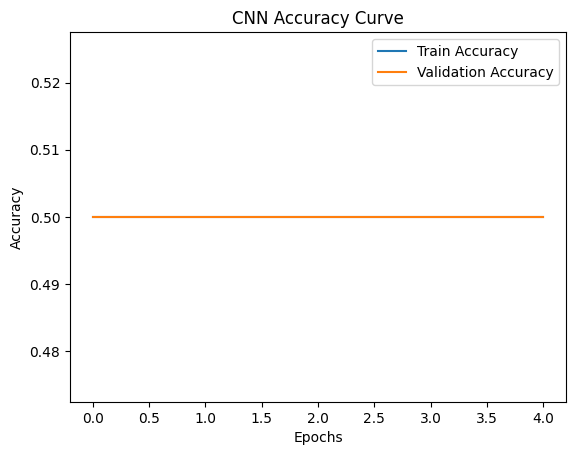

In [46]:
import matplotlib.pyplot as plt

# =========================
# STEP 1: Accuracy Curve
# =========================

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [48]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# model predictions
y_pred = model.predict(X_test)

# convert probabilities to class labels
y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 70s 5s/step


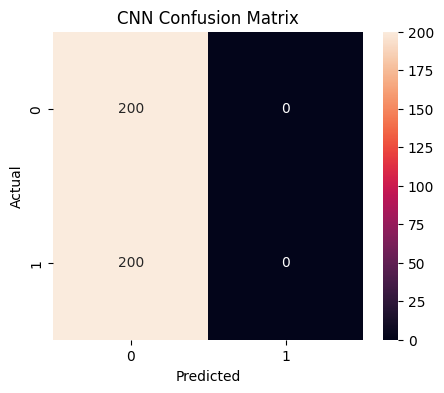

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67       200
           1       0.00      0.00      0.00       200

    accuracy                           0.50       400
   macro avg       0.25      0.50      0.33       400
weighted avg       0.25      0.50      0.33       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
#re do it
import pandas as pd
import os
import glob
df = pd.read_csv(csv_files[0])

df = df[['image file path', 'pathology']]
df = df[df['pathology'].isin(['BENIGN', 'MALIGNANT'])]

df['label'] = df['pathology'].map({
    'BENIGN': 0,
    'MALIGNANT': 1
})
image_paths = glob.glob(path + "/**/*.jpg", recursive=True)

image_dict = {}

for p in image_paths:
    folder_id = p.split('/')[-2]   # IMPORTANT FIX
    image_dict.setdefault(folder_id, []).append(p)
import re

def get_id(text):
    match = re.search(r'P_\d+', text)
    return match.group() if match else None

df['id'] = df['image file path'].apply(get_id)
df['full_path'] = df['id'].apply(lambda x: image_dict.get(x, [None])[0] if x in image_dict else None)

df = df.dropna()
print(len(df))

0


In [40]:
#use resnet 50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [45]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 345s 7s/step - accuracy: 0.5000 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 334s 7s/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 311s 6s/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 340s 7s/step - accuracy: 0.5000 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 329s 7s/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6933


In [47]:
#use DenseNet121
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

In [51]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [52]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [53]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,
    batch_size=32
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5478 - loss: 0.6831